In [3]:
import flopy as fp
import geopandas as gp 
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pathlib import Path
import numpy as np
import pyemu
import platform, shutil
from flopy.export.shapefile_utils import recarray2shp
from flopy.utils.geometry import Polygon


### Set a couple paths to information we will need

In [4]:
#### Base directory for runs
parent_run_path = Path("../../LPR_pycap_opt/pycap_runs")

#### depletion potential calculations directory
base_run_path = parent_run_path / "pycap_base"

#### modflow base path
modflow_run_path = Path('../steady_state_mf6')

#### modflow depletion potential calculations directory
modflow_dp_path = Path('../steady_state_mf6_DP')


### read in the depletion potetial as calculated by `pycap`

In [5]:
dp = gp.read_file(base_run_path / 'depletion_potential.json').to_crs(3071)

### now read in the MODFLOW-6 version of the steady-state Little Plover River Model

In [6]:
sim = fp.mf6.MFSimulation.load(sim_ws = '../steady_state_mf6')
m = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package sfr...
    loading package ic...
    loading package npf...
    loading package oc...
    loading package rch...
    loading package chd...
    loading package drn...
    loading package wel...
  loading solution package lpr_ss_gwf...


### We will need a `modelgrid` object to locate wells and gages on the MODFLOW grid

In [7]:
modelgrid = fp.discretization.StructuredGrid(xoff=1795400*.3048,  
                                             yoff=1424400*.3048,
                                             botm=m.dis.botm.array,
                                             delr = m.dis.delr.array*.3048,
                                             delc = m.dis.delc.array*.3048,
                                                
                                             crs=3071)


### We can look at the main boundaries

Text(0, 0.5, 'Undefined northing, NAD83(HARN) / Wisconsin Transverse Mercator')

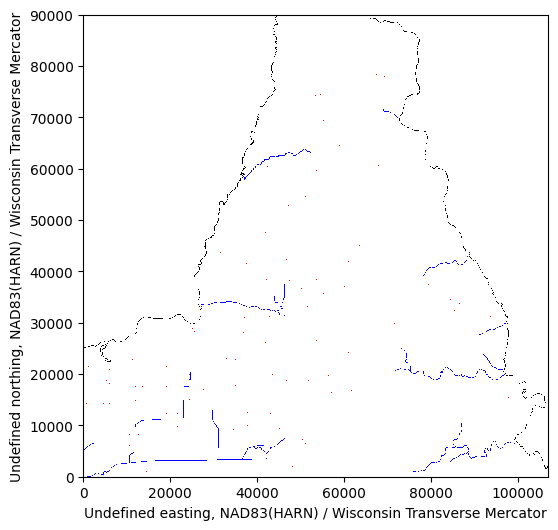

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
pmv = fp.plot.PlotMapView(m, ax=ax)
# lc = pmv.plot_grid(lw=0.5)
pmv.plot_bc("WEL", plotAll=True, color='red')
pmv.plot_bc("SFR", plotAll=True, color='blue')
pmv.plot_bc("CHD", plotAll=True, color='black')
ax.set_xlabel(f'{modelgrid.units.capitalize()} easting, {modelgrid.crs.name}')
ax.set_ylabel(f'{modelgrid.units.capitalize()} northing, {modelgrid.crs.name}')

#### In the figure above, the wells (showing up as kinda faint dots) are red, streams are blue, and constant head boundaries are black. Let's look at these on a map.

### how does the active domain look?

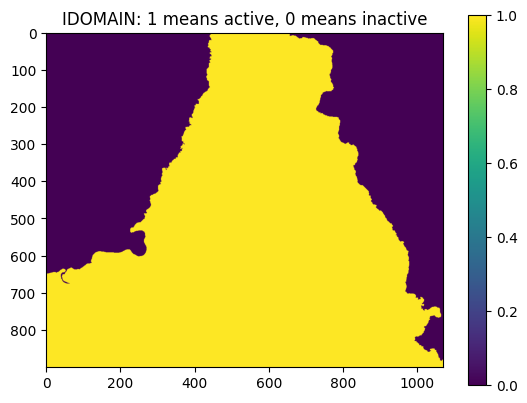

In [9]:
idomain = [[int(i) for i in j.split()] for j in open('../steady_state_mf6/lpr_ss_gwf.dis_idomain_layer1.txt','r').readlines()]
idomain = np.array([k for j in idomain for k in j]).reshape(m.dis.nrow.array,m.dis.ncol.array)
plt.imshow(idomain)
plt.colorbar()
plt.title('IDOMAIN: 1 means active, 0 means inactive');

### Now we need to write out a few shapefiles and then we can explore the model 

In [10]:
modelgrid.write_shapefile('grid.shp') # this is the whole grid. it's a bit cubersome to
                                    # viz though, so we will dissolve it to show only the model outline
grid_shp = gp.read_file('grid.shp').set_crs(3071)
mf6outline = grid_shp.dissolve()

In [11]:
# next let's export the major packages
chds = pd.read_csv('../steady_state_mf6/lpr_ss_gwf.chd_stress_period_data_1.txt', sep=r'\s+', header=None, names = ['k','i','j','head'])
for cc in ['k','i','j']:
    chds[cc]-=1
chds

chd_shp = [Polygon(modelgrid.get_cell_vertices(row, col)) for row, col in zip(chds.i, chds.j)]
recarray2shp(chds.to_records(), geoms=chd_shp, shpname='../steady_state_mf6/chds.shp', crs=modelgrid.crs)
chd_map = gp.read_file('../steady_state_mf6/chds.shp')
chd_map = chd_map.set_crs(modelgrid.crs)

In [12]:
chds

,k,i,j,head
0,0,534,264,1040.00000
1,0,535,265,1040.00000
2,0,536,265,1040.00000
3,0,537,266,1040.00000
4,0,538,266,1040.00000
...,...,...,...,...
5221,1,504,260,1050.95898
5222,1,507,257,1050.95801
5223,1,508,257,1050.95801
5224,1,364,326,1070.66699


### Now check out the blue constant heads on the map. What do these represent? Note - the black box is the outline of the entire model, compare with the IDOMAIN plot above. 

In [10]:
mmap = mf6outline.explore(
 style_kwds={
        "color": "black",   # outline color
        "weight": 2,        # outline thickness (pixels)
        "fillOpacity": 0    # no fill
    },highlight=False
)
chd_map.explore(m=mmap,
               style_kwds={
        "color": "blue",   # outline color
        "fillOpacity": .1    # no fill
    })


## We can now look at the Depletion Potential and set up some comparisons

### note the depletion potential color scale bar - the size also represents depletion potential magnitude

In [11]:
dp.explore(column="Depletion_Potential",
                  vmin=0,vmax=1,m=mmap,
                  style_kwds={"style_function":
                                  lambda x: 
                                  {"radius":x["properties"]["Depletion_Potential"]*15}})


# Let's run the base model and have a look at budget components

In [16]:
# RUN! Should take bewteen 2 and 6 minutes
pyemu.os_utils.run('../../../modflow/mf6', cwd = str(modflow_run_path))

./../../../modflow/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

        MODFLOW 6 compiled Oct  7 2025 22:50:01 with GCC version 12.4.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held liable for any damages resulting from its 
authorized or unauthorized use. Also refer to the USGS Water 
Resources Software User Rights Notice for complete use, copyright, 
and d

In [17]:
# Open a text editor and check out the two `.lst` files in the following location
print(modflow_run_path)

../steady_state_mf6


# We can also use `flopy` to read in the budget information (there are a couple ways to do this - here showing the easiest way)

In [18]:
flux, vol = m.output.list().get_dataframes()

In [19]:
flux

,WEL_IN,DRN_IN,RCHA_IN,CHD_IN,SFR_IN,TOTAL_IN,WEL_OUT,DRN_OUT,RCHA_OUT,CHD_OUT,SFR_OUT,TOTAL_OUT,IN-OUT,PERCENT_DISCREPANCY
1970-01-02,0.0,0.0,13126746.0,1451596.375,419567.03125,14997909.0,3898428.0,206717.703125,0.0,6165540.5,4727554.5,14998241.0,-331.597504,-0.0


# We can check this out in a stacked bar chart as well

Text(0, 0.5, 'Simulated Flux, in $m^3/d$')

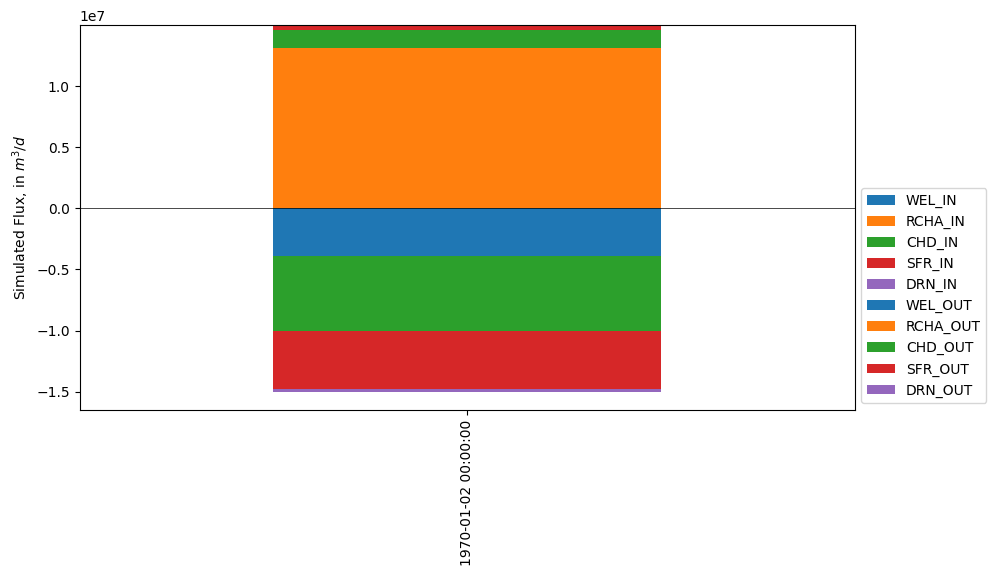

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
in_cols = ['WEL_IN', 'RCHA_IN', 'CHD_IN', 'SFR_IN', 'DRN_IN']
out_cols = [c.replace('_IN', '_OUT') for c in in_cols]
flux[in_cols].plot.bar(stacked=True, ax=ax)
(-flux[out_cols]).plot.bar(stacked=True, ax=ax)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))
ax.axhline(0, lw=0.5, c='k')
ax.set_ylabel('Simulated Flux, in $m^3/d$')